# Import Libraries

In [2]:
import os
import cv2
import numpy as np
import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf

2025-12-08 14:38:30.732020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765204710.923827      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765204710.977535      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Setup and Initialization

In [3]:
# --- Global Parameters ---
base_path = "/kaggle/input/lgg-mri-segmentation/kaggle_3m/"
IMG_SIZE = 256
BATCH_SIZE = 16 # Defined here for convenience in later cells

# Initialize empty lists to store processed data
images = []
masks = []

print("Initialization complete. Starting data file search...")

Initialization complete. Starting data file search...


# Data Loading and Path Matching

In [4]:
# Cell 1.2: Data Loading and Path Matching

print("Loading data and pairing images with masks...")
for patient_folder in os.listdir(base_path):
    patient_path = os.path.join(base_path, patient_folder)
    if not os.path.isdir(patient_path):
        continue
    
    # Find all mask files for the current patient
    mask_files = glob.glob(os.path.join(patient_path, "*_mask.tif"))
    
    for mask_file in mask_files:
        # Infer the original image file name by removing '_mask'
        img_file = mask_file.replace('_mask', '') 
        
        if not os.path.exists(img_file):
            continue

        # Read image and mask as grayscale (1 channel)
        img = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)

        # Append raw data to lists for batch processing in the next cell
        images.append(img)
        masks.append(mask)

# Convert lists to NumPy arrays
images = np.array(images)
masks = np.array(masks)
print(f"Raw data loaded. Total samples: {images.shape[0]}.")

Loading data and pairing images with masks...
Raw data loaded. Total samples: 3929.


# Image and Mask Preprocessing

In [5]:
# Cell 1.3: Image and Mask Preprocessing

def process_data(data, is_mask=False):
    """Resizes, normalizes/binarizes, and adds channel dimension."""
    processed_data = []
    for item in data:
        # Resize to IMG_SIZE x IMG_SIZE
        resized_item = cv2.resize(item, (IMG_SIZE, IMG_SIZE))
        
        if not is_mask:
            # Normalize images (0 to 1)
            resized_item = resized_item / 255.0
        else:
            # Binarize masks (Any non-zero value becomes 1.0)
            resized_item[resized_item > 0] = 1.0
        
        # Add channel dimension (256, 256, 1) and cast to float32
        item_with_channel = np.expand_dims(resized_item, axis=-1).astype(np.float32)
        processed_data.append(item_with_channel)
        
    return np.array(processed_data)

print("Starting image and mask preprocessing...")

# Process images and masks
images_processed = process_data(images, is_mask=False)
masks_processed = process_data(masks, is_mask=True)

print(f"Processed Images shape: {images_processed.shape}")
print(f"Processed Masks shape: {masks_processed.shape}")

Starting image and mask preprocessing...
Processed Images shape: (3929, 256, 256, 1)
Processed Masks shape: (3929, 256, 256, 1)


# Data Splitting

In [6]:
# Cell 1.4: Data Splitting (Train: 70%, Test: 15%, Validation: 15%)

# First split: Separate 30% for Test/Validation
X_train, X_temp, y_train, y_temp = train_test_split(
    images_processed, 
    masks_processed, 
    test_size=0.3, 
    random_state=42
)

# Second split: Divide the remaining 30% equally into Test and Validation (15% each)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.5, # 0.5 of the 30% (i.e., 15% overall)
    random_state=42
)

print("\nData Splitting Complete:")
print(f"Train shapes: {X_train.shape} / {y_train.shape} (70%)")
print(f"Validation shapes: {X_val.shape} / {y_val.shape} (15%)")
print(f"Test shapes: {X_test.shape} / {y_test.shape} (15%)")


Data Splitting Complete:
Train shapes: (2750, 256, 256, 1) / (2750, 256, 256, 1) (70%)
Validation shapes: (590, 256, 256, 1) / (590, 256, 256, 1) (15%)
Test shapes: (589, 256, 256, 1) / (589, 256, 256, 1) (15%)


# Exploratory Data Analysis (EDA)

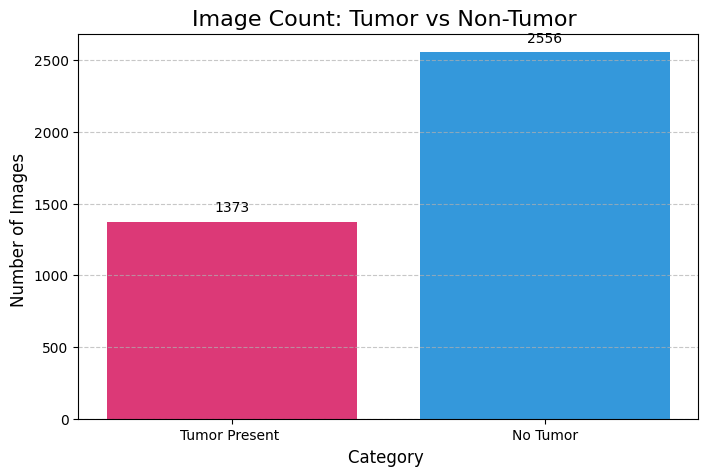

Total Images: 3929
Tumor Present: 1373
No Tumor: 2556

Displaying 7 random sample images with their status...


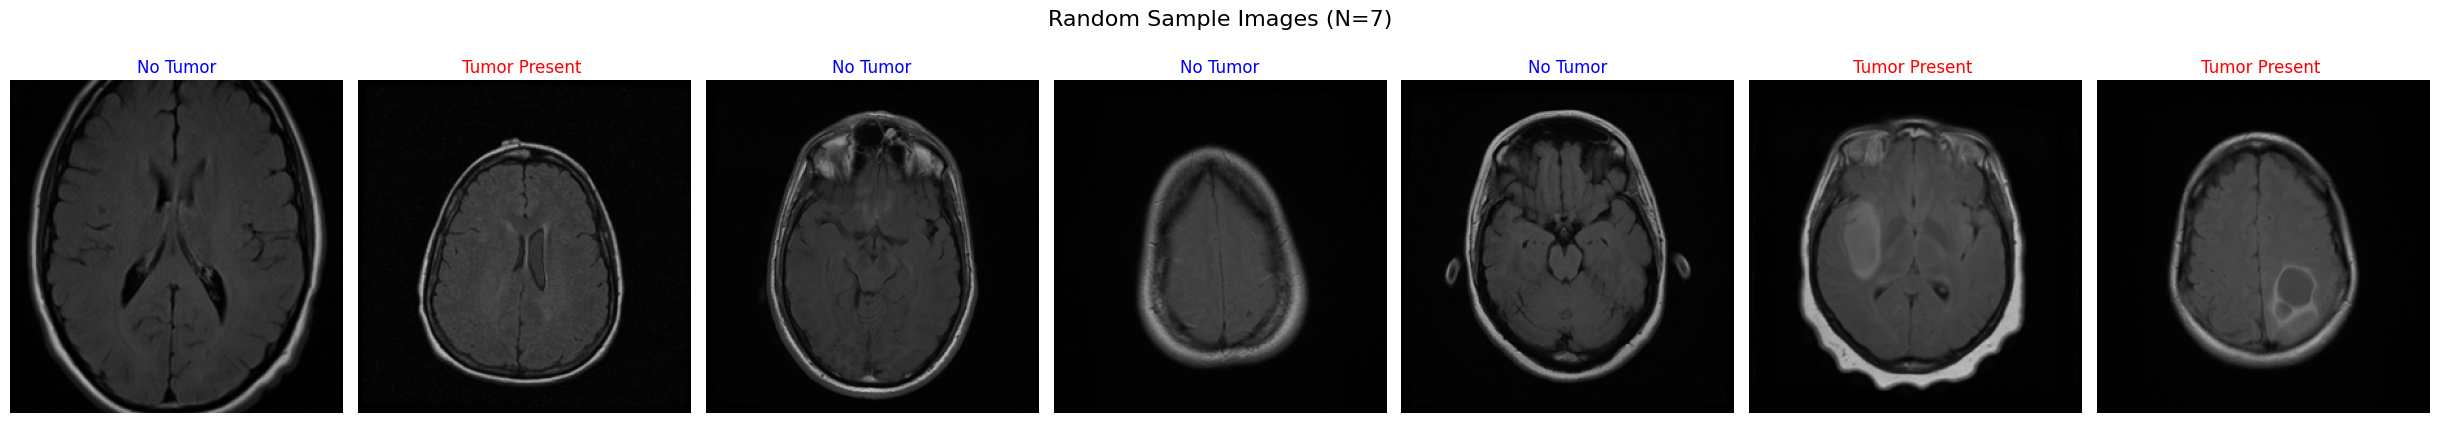


EDA complete. The bar chart confirms class imbalance, and the visualization shows sample quality.


In [7]:
# C Exploratory Data Analysis (EDA) - Consolidated

import matplotlib.pyplot as plt
import random
import numpy as np

# --- 2.1 Image Count per Class (Bar Chart) ---

has_tumor = np.sum(np.sum(masks_processed, axis=(1, 2)) > 0)
no_tumor = images_processed.shape[0] - has_tumor

counts = {"Tumor Present ": has_tumor, "No Tumor": no_tumor}

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.keys(), counts.values(), color=["#DC3977", "#3498DB"])
plt.title("Image Count: Tumor vs Non-Tumor ", fontsize=16)
plt.xlabel("Category ", fontsize=12)
plt.ylabel("Number of Images ", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.bar_label(bars, padding=5)
plt.show()

print(f"Total Images: {images_processed.shape[0]}")
print(f"Tumor Present: {has_tumor}")
print(f"No Tumor: {no_tumor}")

# --- 2.2 Simple Sample Visualization (MRI Images Only) ---
def visualize_simple_samples(images, masks, n_cols=5):
    """
    Displays a limited number of random MRI images and labels their tumor status.
    """
    # Select random indices for display
    indices = random.sample(range(len(images)), n_cols)
    plt.figure(figsize=(3.5 * n_cols, 4))
    
    for i, idx in enumerate(indices):
        image_2d = images[idx].squeeze() # Get 2D image
        mask_2d = masks[idx].squeeze()
        
        # Check status
        is_tumor = np.sum(mask_2d) > 0
        status_label = "Tumor Present " if is_tumor else "No Tumor"
        
        # Plotting the image
        plt.subplot(1, n_cols, i + 1)
        plt.imshow(image_2d, cmap='gray', vmin=0, vmax=1) # Display image with correct 0-1 range
        plt.title(status_label, fontsize=12, color='red' if is_tumor else 'blue')
        plt.axis("off")
        
    plt.suptitle(f"Random Sample Images (N={n_cols})", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

print("\nDisplaying 7 random sample images with their status...")
visualize_simple_samples(images_processed, masks_processed, n_cols=7)

print("\nEDA complete. The bar chart confirms class imbalance, and the visualization shows sample quality.")

# Data Augmentation

In [8]:
#  Data Augmentation Implementation

from tensorflow.keras.preprocessing.image import ImageDataGenerator
BATCH_SIZE = 16
EPOCHS = 20
# 1. Define Augmentation Parameters (Common for Segmentation)
# We choose transformations that maintain the spatial relationship
data_gen_args = dict(
    rotation_range=20,          # Rotate image randomly up to 20 degrees
    width_shift_range=0.05,     # Shift image horizontally (fraction of total width)
    height_shift_range=0.05,    # Shift image vertically (fraction of total height)
    shear_range=0.05,           # Apply shear mapping
    zoom_range=0.05,            # Randomly zoom in/out
    horizontal_flip=True,       # Flip image horizontally (VERY useful for medical images)
    fill_mode='nearest'         # Strategy for filling in newly created pixels
)

# 2. Create the Data Generator
# Generator for Training Images
image_datagen = ImageDataGenerator(**data_gen_args)
image_generator = image_datagen.flow(
    X_train,
    batch_size=BATCH_SIZE, # Use BATCH_SIZE from Step 5
    seed=42,               # Use a fixed seed for reproducibility
    shuffle=True
)

# Generator for Training Masks
mask_datagen = ImageDataGenerator(**data_gen_args)
mask_generator = mask_datagen.flow(
    y_train,
    batch_size=BATCH_SIZE, 
    seed=42,              
    shuffle=True
)

# 3. Create a Combined Generator (Yields (Image_Batch, Mask_Batch))
def combine_generators(gen1, gen2):
    """Combines two generators into one that yields paired batches."""
    while True:
        X_batch = next(gen1) 
        Y_batch = next(gen2)
        yield (X_batch, Y_batch)

train_generator = combine_generators(image_generator, mask_generator)
print("Data Augmentation Generators created for training set.")

Data Augmentation Generators created for training set.


# U-Net Model Definition

In [9]:
# : U-Net Model Definition

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout

# Assuming IMG_SIZE is defined from Cell 1 (e.g., IMG_SIZE = 256)
IMG_SIZE = 256 # Define IMG_SIZE again for safety if running this cell independently

def unet_model(input_size=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = Input(input_size)
    
    # Encoder (Downsampling path)
    
    # Block 1
    conv1 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    conv1 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    
    # Block 2
    conv2 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool1)
    conv2 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    
    # Block 3
    conv3 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool2)
    conv3 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    
    # Bottleneck
    conv4 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool3)
    conv4 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)
    
    # Decoder (Upsampling path with skip connections)
    
    # Block 5 (merges with conv3)
    up5 = Conv2D(64, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(drop4))
    merge5 = concatenate([conv3, up5], axis=3)
    conv5 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge5)
    conv5 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv5)
    
    # Block 6 (merges with conv2)
    up6 = Conv2D(32, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv5))
    merge6 = concatenate([conv2, up6], axis=3)
    conv6 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge6)
    conv6 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv6)

    # Block 7 (merges with conv1)
    up7 = Conv2D(16, 2, activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv6))
    merge7 = concatenate([conv1, up7], axis=3)
    conv7 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge7)
    conv7 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv7)
    
    # Output Layer: 1 channel (Binary Segmentation) using Sigmoid activation
    conv8 = Conv2D(1, 1, activation='sigmoid')(conv7)

    model = Model(inputs=inputs, outputs=conv8)
    return model

# Create the model instance
model = unet_model()
print("U-Net Model created.")

I0000 00:00:1765204800.771756      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


U-Net Model created.


# Metrics and Loss Functions

In [10]:
# Metrics and Loss Functions

from tensorflow.keras import backend as K
import tensorflow as tf

# 1. Dice Coefficient (F1-Score)
# A measure of the overlap between the predicted mask and the ground truth mask.
def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    # The formula is 2 * (Intersection) / (Total elements in both sets)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# 2. IoU (Jaccard Index)
# Intersection over Union. A standard metric for segmentation quality.
def iou_score(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# 3. Dice Loss (1 - Dice Coef)
def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# 4. Combined Loss (Binary Crossentropy + Dice Loss)
# Combining BCE (good for penalizing overall difference) with Dice Loss (good for class imbalance/overlap)
def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)


# Compile the model
model.compile(optimizer='adam', 
              loss=combined_loss, 
              metrics=['accuracy', dice_coef, iou_score])

print("Model compiled with Combined Loss, Dice Coef, and IoU Score.")

Model compiled with Combined Loss, Dice Coef, and IoU Score.


# Model Training

In [11]:
# Model Training 

# BATCH_SIZE = 16 
EPOCHS = 20 
steps_per_epoch = len(X_train) // BATCH_SIZE

# Train the model using the combined generator
print(f"Starting training for {EPOCHS} epochs using Data Augmentation...")
history = model.fit(
    train_generator,               # Use the combined generator for augmented training data
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    verbose=1,
    validation_data=(X_val, y_val), # Validation data remains non-augmented (for true performance measure)
    shuffle=False                  # Shuffling is handled by the generators themselves
)

print("Training finished with Data Augmentation.")

Starting training for 20 epochs using Data Augmentation...
Epoch 1/20


I0000 00:00:1765204810.070375      70 service.cc:148] XLA service 0x7a936c001fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765204810.071196      70 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765204810.915166      70 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/171 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.9088 - dice_coef: 0.0238 - iou_score: 0.0121 - loss: 1.6168 

I0000 00:00:1765204820.966277      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


171/171 ━━━━━━━━━━━━━━━━━━━━ 49s 180ms/step - accuracy: 0.9827 - dice_coef: 0.1050 - iou_score: 0.0579 - loss: 1.0222 - val_accuracy: 0.9758 - val_dice_coef: 0.2196 - val_iou_score: 0.1254 - val_loss: 0.8421
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 32s 131ms/step - accuracy: 0.9805 - dice_coef: 0.2145 - iou_score: 0.1262 - loss: 0.8516 - val_accuracy: 0.9894 - val_dice_coef: 0.2602 - val_iou_score: 0.1611 - val_loss: 0.8007
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - accuracy: 0.9842 - dice_coef: 0.2631 - iou_score: 0.1601 - loss: 0.8011 - val_accuracy: 0.9645 - val_dice_coef: 0.2285 - val_iou_score: 0.1306 - val_loss: 0.8736
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - accuracy: 0.9789 - dice_coef: 0.2763 - iou_score: 0.1674 - loss: 0.7959 - val_accuracy: 0.9895 - val_dice_coef: 0.2754 - val_iou_score: 0.1745 - val_loss: 0.7873
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step - accuracy: 0.9852 - dice_coef: 0.3011 - iou_score: 0.1909 - loss: 0.7601 - val_

# Evaluation and Results


Evaluating model on Test Set...
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9931 - dice_coef: 0.6135 - iou_score: 0.4529 - loss: 0.4304

--- Model Evaluation Results ---
Loss (Combined Loss): 0.4581
Accuracy: 0.9927
Dice Coefficient (Target > 0.8): 0.5884
IoU Score (Target > 0.8): 0.4272
--------------------------------

Displaying True vs. Predicted Masks for 5 random samples...


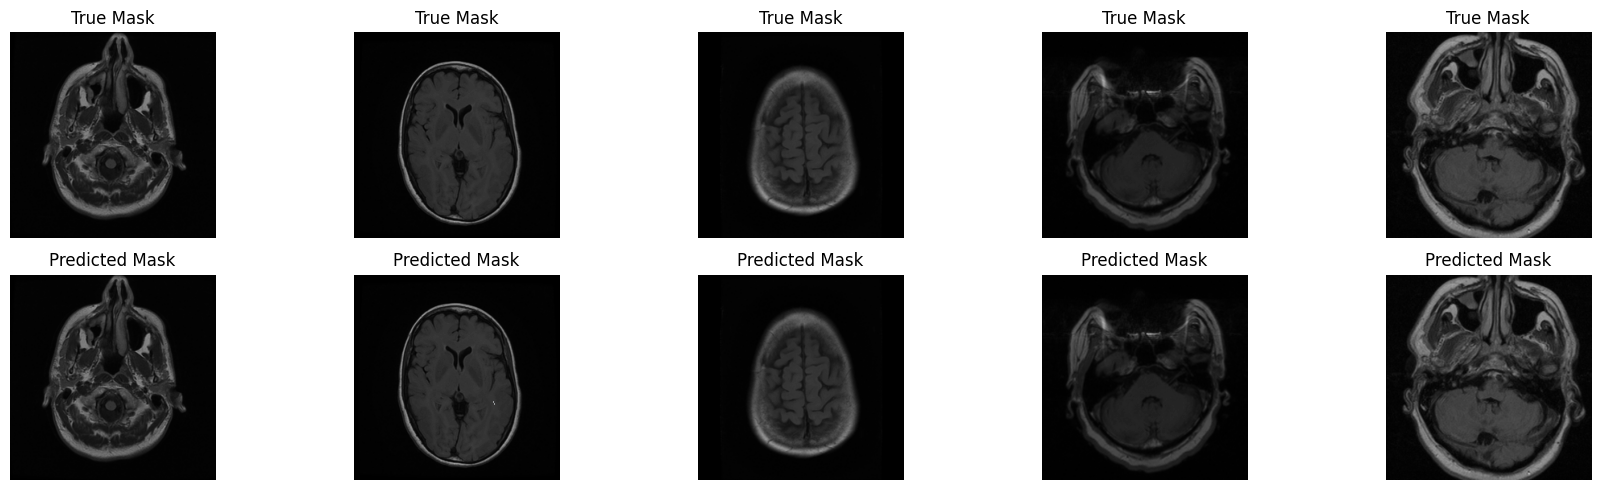

In [12]:
# Evaluation and Results

import matplotlib.pyplot as plt
import numpy as np

# Evaluate the model on the non-augmented test set
print("\nEvaluating model on Test Set...")
# Ensure BATCH_SIZE is defined (e.g., BATCH_SIZE = 16)
results = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=1)

# Results order: [loss, accuracy, dice_coef, iou_score]
loss, accuracy, dice, iou = results

# Display the final results
print("\n--- Model Evaluation Results ---")
print(f"Loss (Combined Loss): {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Dice Coefficient (Target > 0.8): {dice:.4f}")
print(f"IoU Score (Target > 0.8): {iou:.4f}")
print("--------------------------------")

# --- Visualization Function ---
def display_predictions(images, masks, n=5):
    """
    Display original image, true mask overlay, and predicted mask overlay 
    for random samples from the test set.
    """
    
    sample_indices = np.random.choice(len(images), n, replace=False)
    
    plt.figure(figsize=(18, 5)) 
    
    for i, idx in enumerate(sample_indices):
        img = images[idx:idx+1]
        
        # Predict the mask
        pred_mask = model.predict(img, verbose=0)[0].squeeze()
        # Apply binary threshold (0.5)
        pred_mask_binary = (pred_mask > 0.5).astype(np.float32) 
        
        # --- True Mask Overlay (Top Row) ---
        ax1 = plt.subplot(2, n, i + 1)
        # Display grayscale image
        plt.imshow(img[0].squeeze(), cmap='gray', vmin=0, vmax=1)
        
        # Overlay the True Mask (Reds)
        true_mask_overlay = np.ma.masked_where(masks[idx].squeeze() == 0, masks[idx].squeeze())
        plt.imshow(true_mask_overlay, cmap='Reds', alpha=0.5)
        
        plt.title(f"True Mask")
        plt.axis('off')
        
        # --- Predicted Mask Overlay (Bottom Row) ---
        ax2 = plt.subplot(2, n, i + n + 1)
        # Display grayscale image
        plt.imshow(img[0].squeeze(), cmap='gray', vmin=0, vmax=1)
        
        # Overlay the Predicted Mask (Blues)
        pred_mask_overlay = np.ma.masked_where(pred_mask_binary == 0, pred_mask_binary)
        plt.imshow(pred_mask_overlay, cmap='Blues', alpha=0.5)
        
        plt.title(f"Predicted Mask")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Display 5 random samples from the test set
print("\nDisplaying True vs. Predicted Masks for 5 random samples...")
display_predictions(X_test, y_test, n=5)

# Training History Visualization

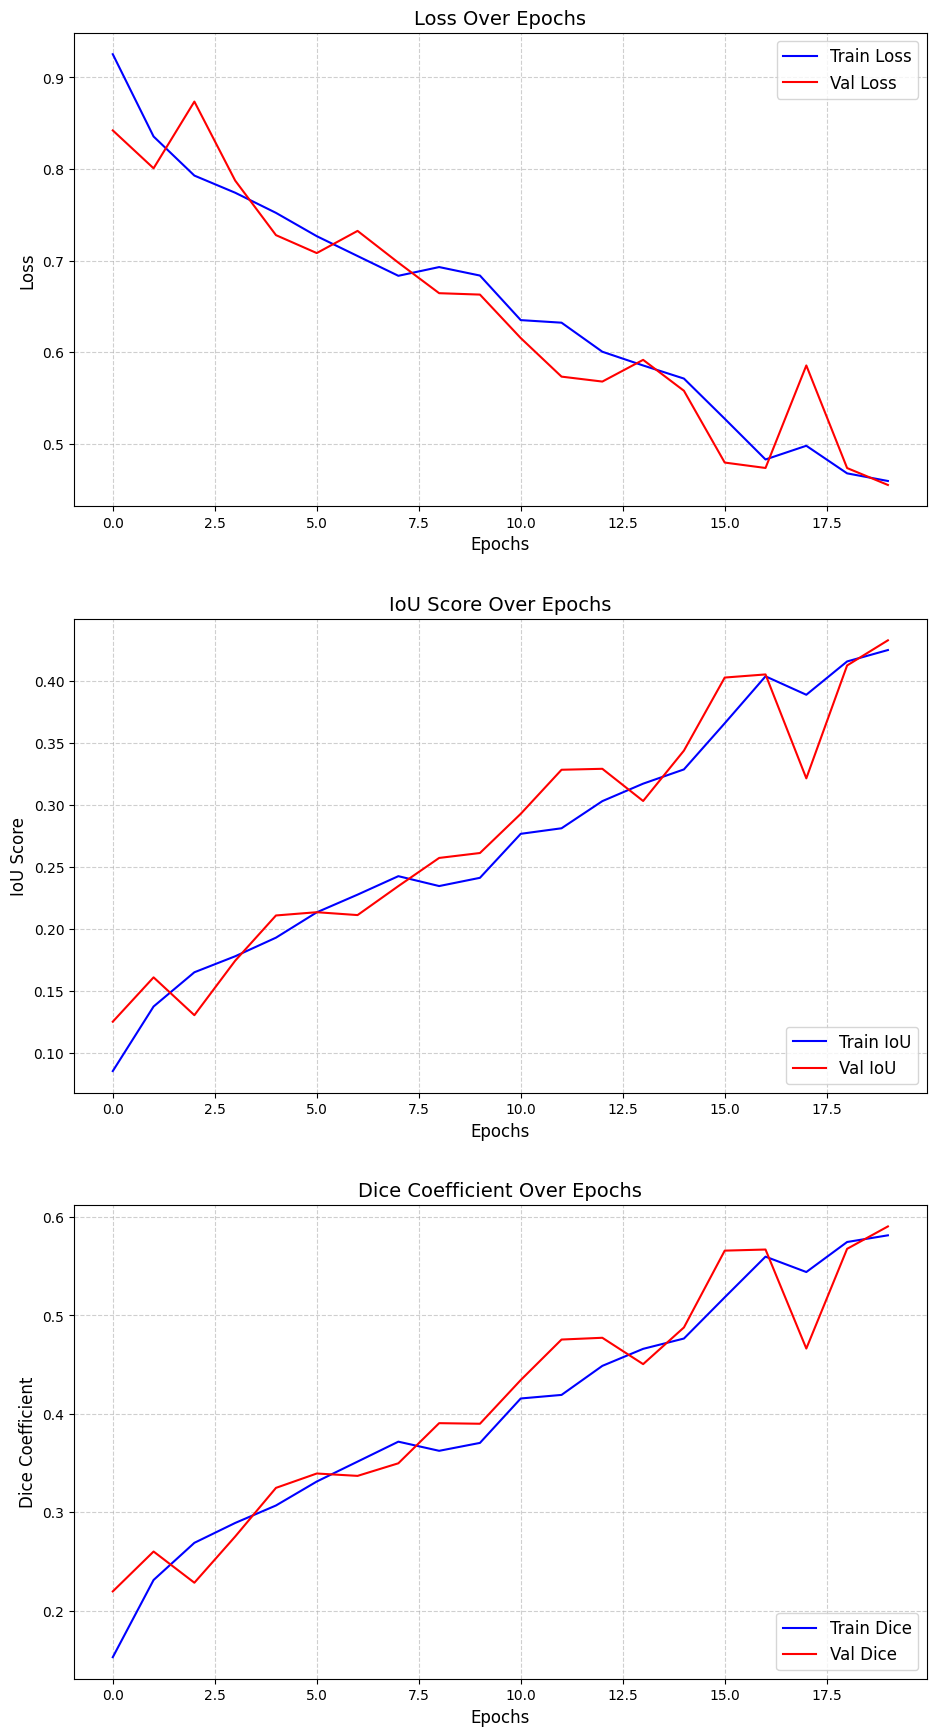

In [13]:
# Training History Visualization

import matplotlib.pyplot as plt

# Check if 'history' object exists and contains training metrics
if 'history' not in locals() or history is None:
    print("Error: The 'history' object is not available or the training cell (Cell 5) was not run successfully.")
elif not history.history:
    print("Error: The 'history' object is empty. Training might have failed.")
else:
    # Set up the figure size for 3 stacked plots
    plt.figure(figsize=(10, 18)) # Increased width slightly for better readability

    # --- 1. Loss ---
    plt.subplot(3, 1, 1)
    plt.plot(history.history['loss'], 'b-', label='Train Loss')
    # Use 'val_loss' for Validation Loss
    plt.plot(history.history['val_loss'], 'r-', label='Val Loss') 
    plt.legend(loc='upper right', fontsize=12)
    plt.title('Loss Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- 2. IoU (Jaccard Index) ---
    plt.subplot(3, 1, 2)
    # The metric name in Keras history object is usually the function name
    plt.plot(history.history['iou_score'], 'b-', label='Train IoU')
    plt.plot(history.history['val_iou_score'], 'r-', label='Val IoU')
    plt.legend(loc='lower right', fontsize=12)
    plt.title('IoU Score Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('IoU Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- 3. Dice Coefficient ---
    plt.subplot(3, 1, 3)
    plt.plot(history.history['dice_coef'], 'b-', label='Train Dice')
    plt.plot(history.history['val_dice_coef'], 'r-', label='Val Dice')
    plt.legend(loc='lower right', fontsize=12)
    plt.title('Dice Coefficient Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Dice Coefficient', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(pad=3.0) # Add padding between subplots
    plt.show()

# Visualization with Bounding Box

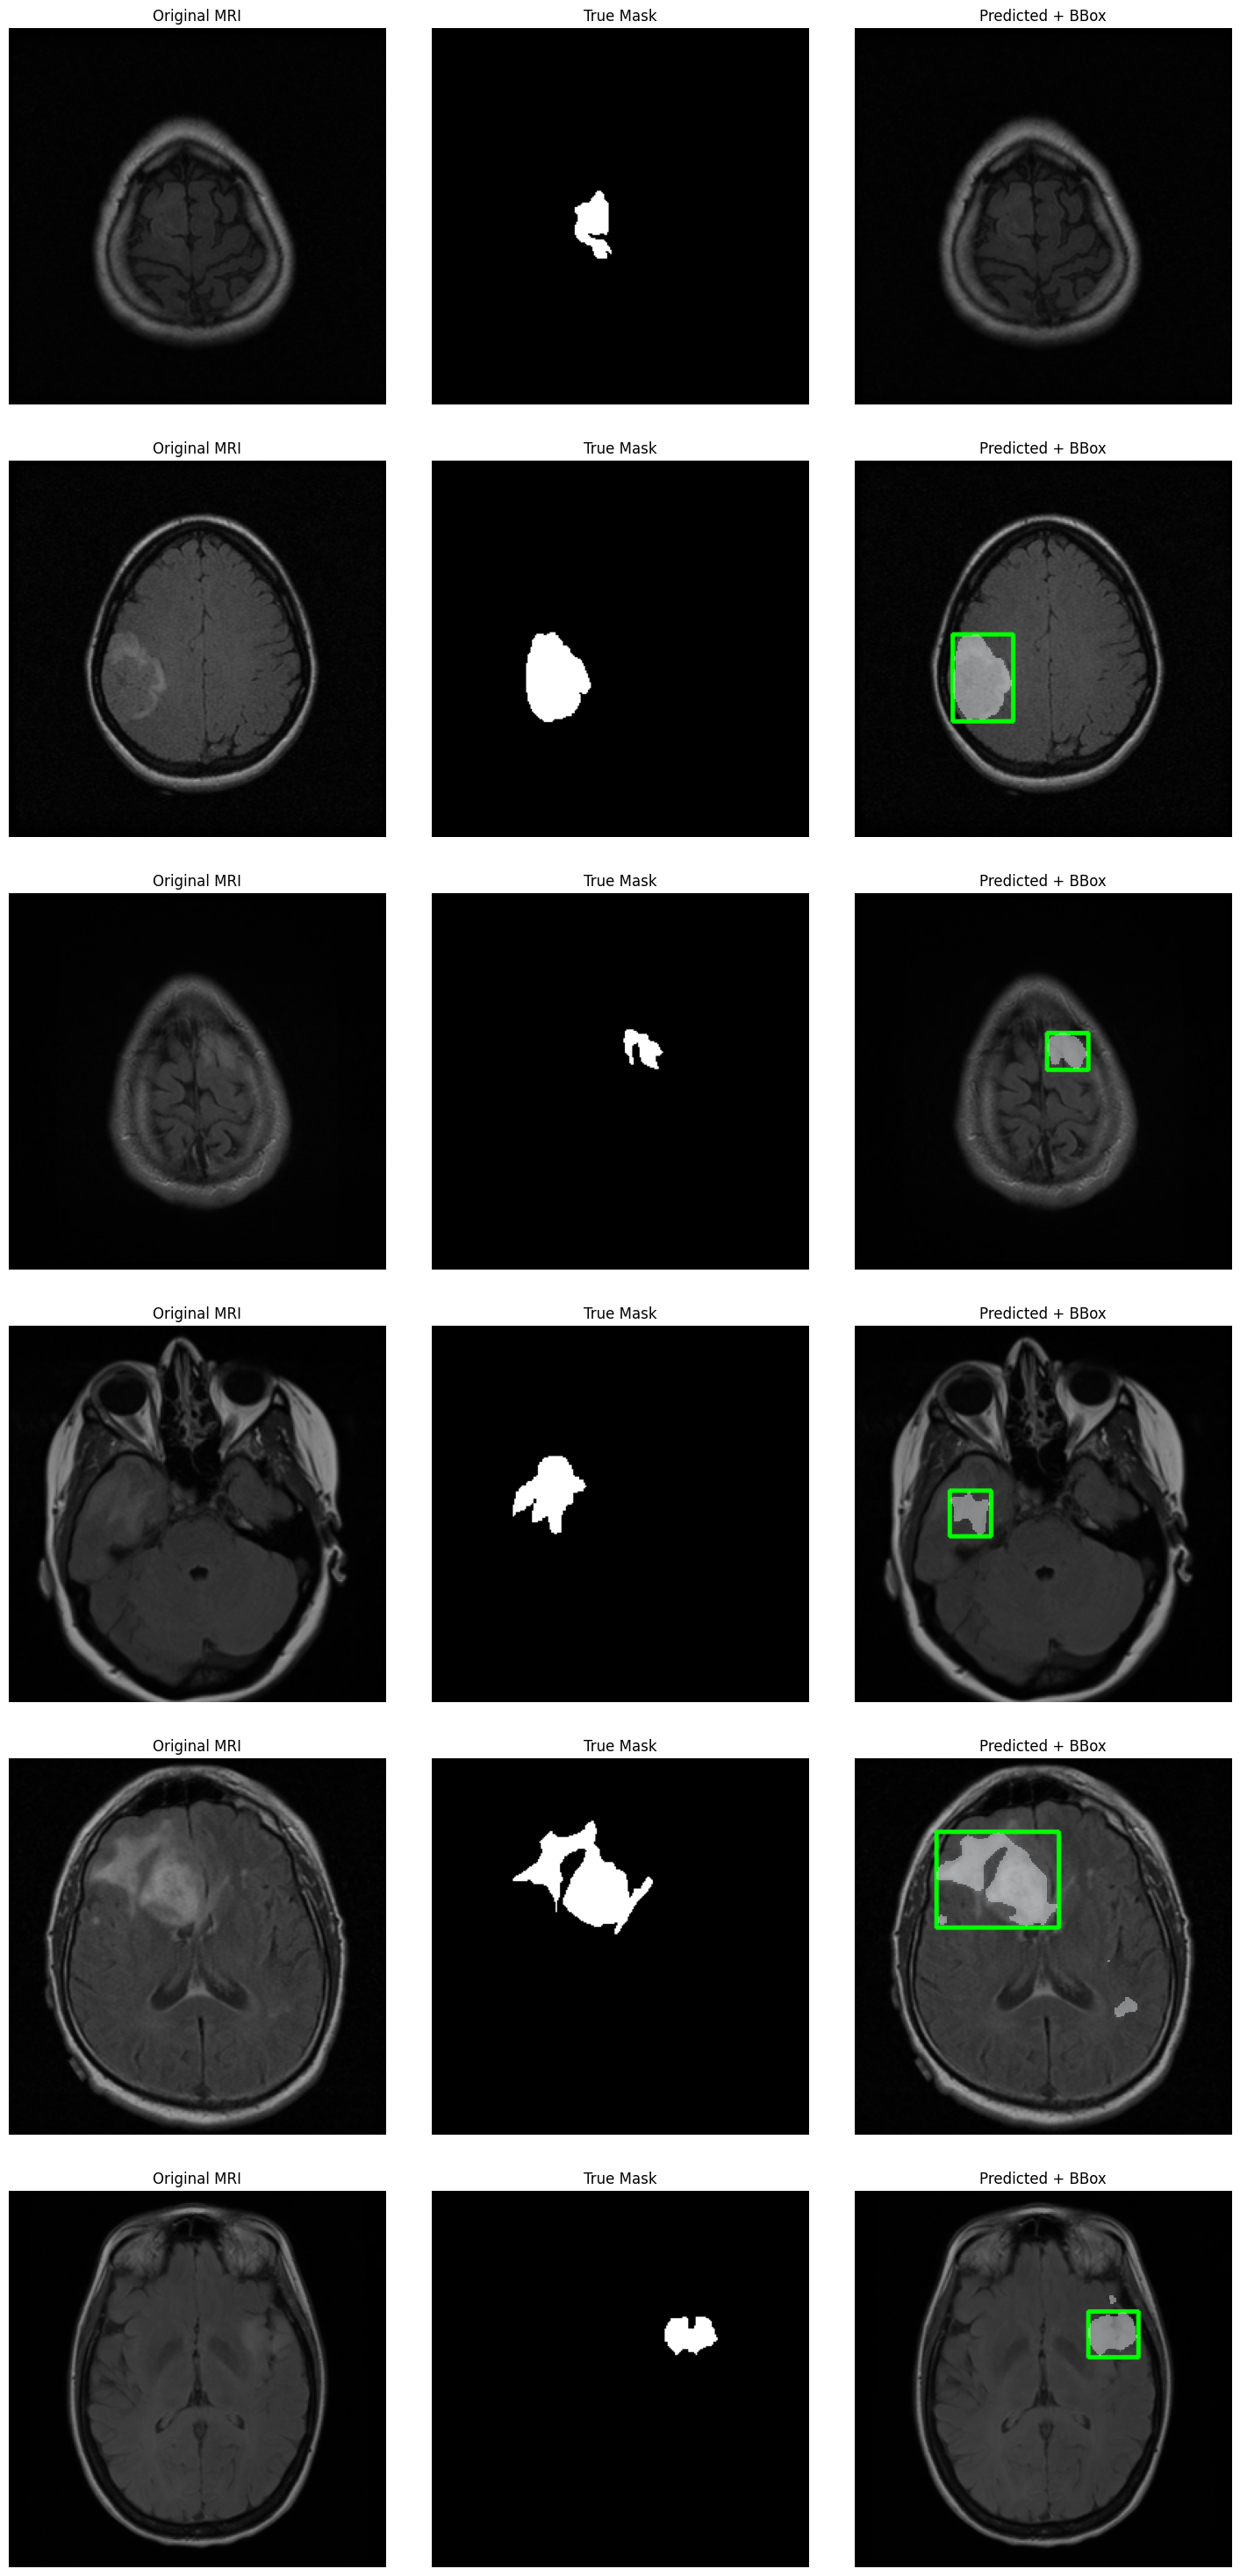

In [14]:
# Cell 11: Combined Visualization (Original + True Mask + Predicted with BBox)

import matplotlib.pyplot as plt
import numpy as np
import random
import cv2 # Ensure cv2 is imported

def visualize_combined_results(model, X_test, y_test, num_samples=2, threshold=0.5):
    """
    Visualizes original MRI, ground truth mask, and predicted mask with bounding box,
    in a 3-column layout per sample.
    """
    
    # 1. Select random indices for visualization
    # We will pick samples that actually have a tumor for clearer demonstration
    tumor_indices = [i for i in range(len(y_test)) if np.any(y_test[i] > 0)]
    if len(tumor_indices) < num_samples:
        print(f"Warning: Not enough tumor samples to display {num_samples}. Displaying {len(tumor_indices)} instead.")
        selected_indices = random.sample(tumor_indices, len(tumor_indices))
    else:
        selected_indices = random.sample(tumor_indices, num_samples)

    total_display_samples = len(selected_indices)
    
    # Set up the figure for 3 columns per sample
    plt.figure(figsize=(15, total_display_samples * 5)) # Adjusted height for clarity

    for i, idx in enumerate(selected_indices):
        # --- Data Preparation ---
        image_float = X_test[idx].squeeze()  # Original image (0-1 float)
        true_mask_float = y_test[idx].squeeze() # True mask (0-1 float)

        # Convert original image to 8-bit uint8 for display and OpenCV
        image_uint8 = (image_float * 255).astype(np.uint8)
        
        # Predict mask
        pred_raw = model.predict(np.expand_dims(X_test[idx], axis=0), verbose=0)[0]
        pred_mask_binary = (pred_raw.squeeze() > threshold).astype(np.float32) # Binary 0 or 1 mask
        pred_mask_uint8 = (pred_mask_binary * 255).astype(np.uint8) # 0/255 uint8 for cv2

        # --- Bounding Box Logic ---
        # Convert grayscale image to BGR color for drawing (necessary for colored box)
        image_bgr_for_bbox = cv2.cvtColor(image_uint8, cv2.COLOR_GRAY2BGR)
        
        # Find contours on predicted mask
        contours, _ = cv2.findContours(pred_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        image_with_bbox_bgr = image_bgr_for_bbox.copy()
        
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest_contour) > 5: # Filter small contours
                x, y, w, h = cv2.boundingRect(largest_contour)
                cv2.rectangle(image_with_bbox_bgr, (x, y), (x + w, y + h), (0, 255, 0), 2) # Green BBox
        
        # Convert back to RGB for Matplotlib (for the BBox plot)
        image_with_bbox_rgb = cv2.cvtColor(image_with_bbox_bgr, cv2.COLOR_BGR2RGB)
        
        # --- Plotting ---
        
        # 1. Original MRI
        plt.subplot(total_display_samples, 3, i*3 + 1)
        plt.imshow(image_uint8, cmap='gray', vmin=0, vmax=255) # Ensure grayscale display
        plt.title("Original MRI", fontsize=12)
        plt.axis("off")

        # 2. True Mask (Pure Black and White)
        plt.subplot(total_display_samples, 3, i*3 + 2)
        plt.imshow(true_mask_float, cmap='gray', vmin=0, vmax=1) # Pure B&W for mask
        plt.title("True Mask", fontsize=12)
        plt.axis("off")

        # 3. Predicted Mask + Bounding Box (Overlay)
        plt.subplot(total_display_samples, 3, i*3 + 3)
        plt.imshow(image_with_bbox_rgb) # Image with BBox
        
        # Overlay the predicted mask (blue, transparent)
        pred_mask_overlay = np.ma.masked_where(pred_mask_binary == 0, pred_mask_binary)
        plt.imshow(pred_mask_overlay, cmap='Blues', alpha=0.4) # Blue overlay for predicted
        
        plt.title("Predicted + BBox", fontsize=12)
        plt.axis("off")

    plt.tight_layout(pad=3.0)
    plt.show()

# Run the visualization for a few samples (e.g., 2 as in your image, or 4 for more examples)
visualize_combined_results(model, X_test, y_test, num_samples=6)

# Tumer prediction

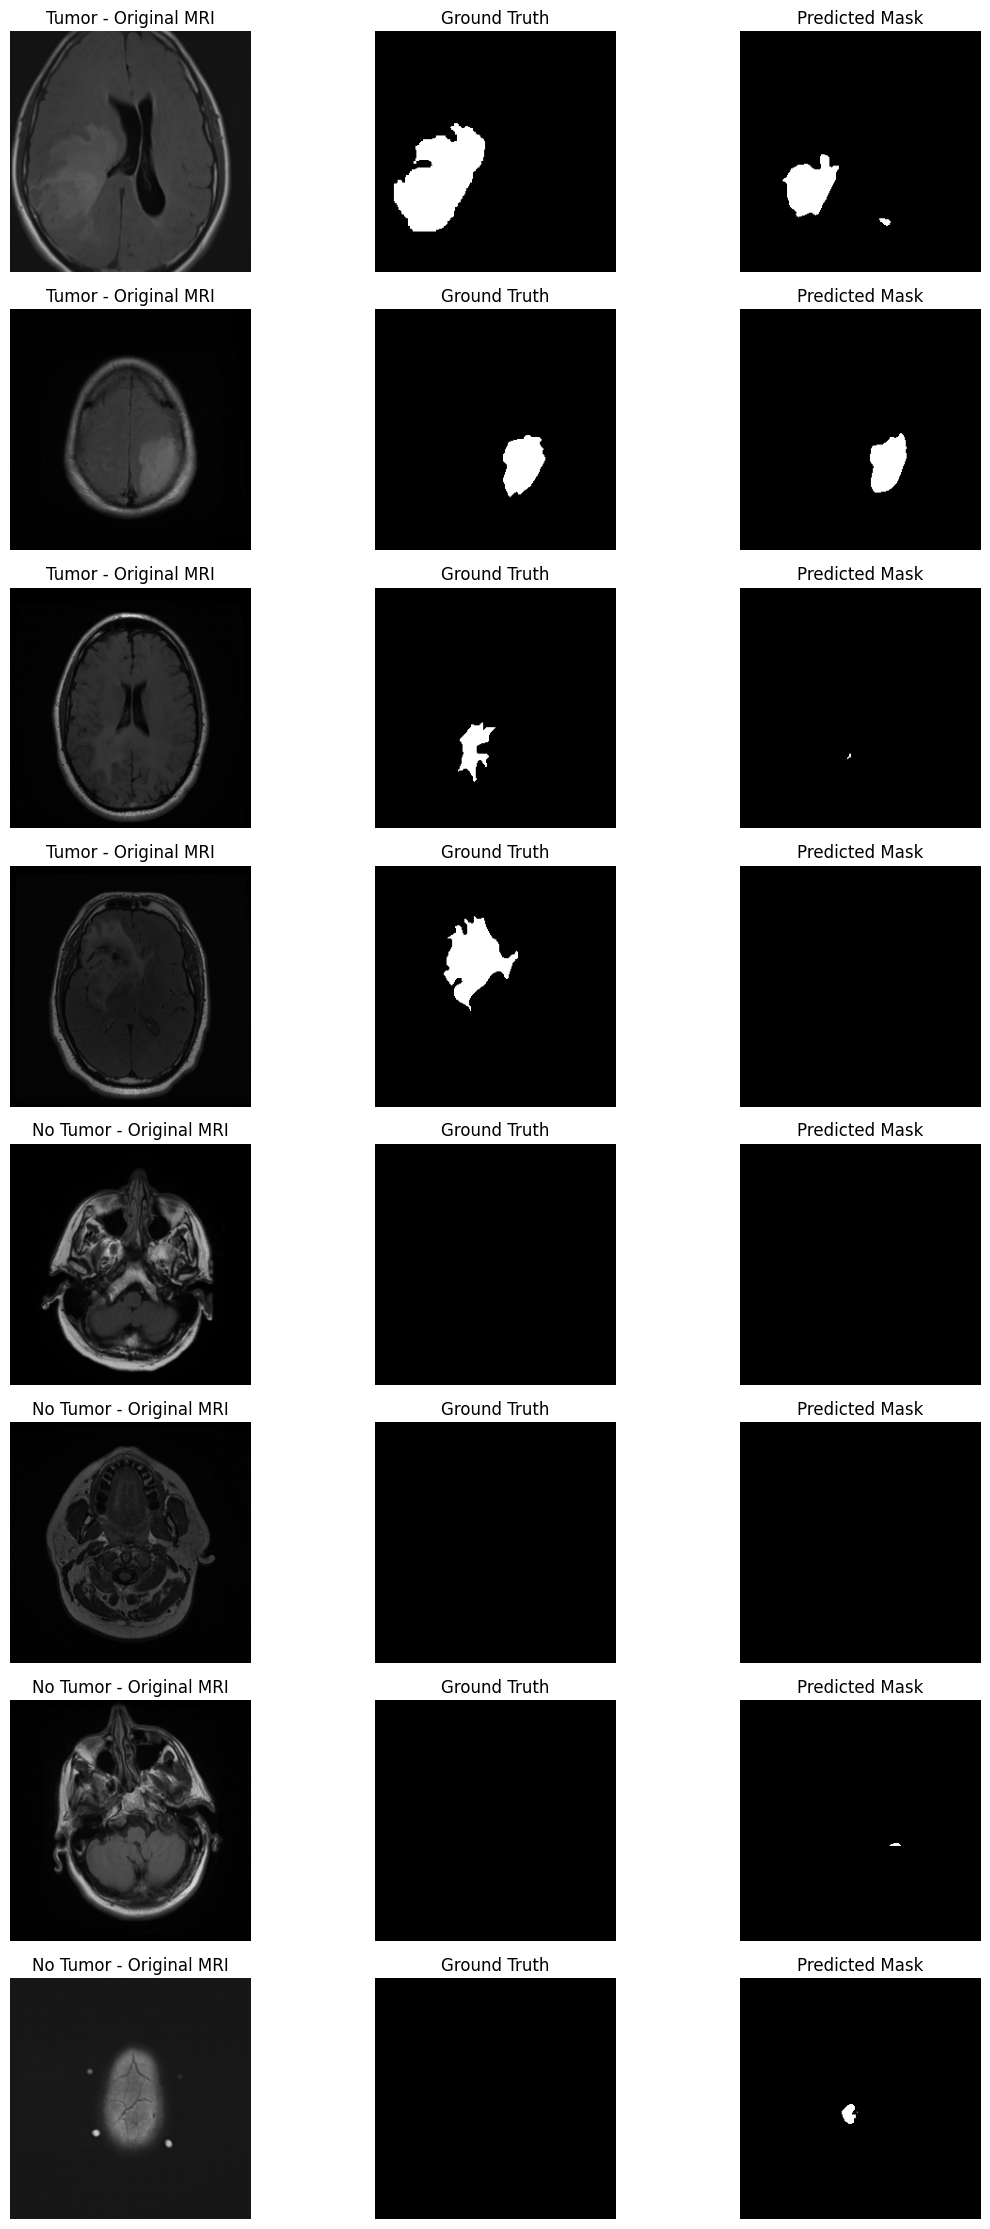

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import random
import tensorflow as tf # Required for model.predict

def visualize_predictions_balanced(model, X_test, y_test, num_per_class=4):
    """
    Visualize a balanced set of tumor and non-tumor samples with 
    original MRI, ground truth mask, and predicted mask.
    """
    
    # 1. Prepare indices and select balanced samples
    # Flatten masks to detect presence of tumor (any pixel > 0)
    tumor_indices = [i for i in range(len(y_test)) if np.any(y_test[i] > 0)]
    non_tumor_indices = [i for i in range(len(y_test)) if not np.any(y_test[i] > 0)]

    # Ensure enough samples exist in both categories
    tumor_indices = random.sample(tumor_indices, min(num_per_class, len(tumor_indices)))
    non_tumor_indices = random.sample(non_tumor_indices, min(num_per_class, len(non_tumor_indices)))

    selected_indices = tumor_indices + non_tumor_indices
    total_samples = len(selected_indices) # Should be up to 8

    # Set up the figure size (3 columns: MRI, True, Predicted)
    plt.figure(figsize=(12, total_samples * 2.8)) 

    # 2. Loop through selected samples and plot results
    for i, idx in enumerate(selected_indices):
        image = X_test[idx]
        true_mask = y_test[idx]

        # Predict mask
        # Note: model.predict requires an expanded batch dimension
        pred_mask_raw = model.predict(np.expand_dims(image, axis=0), verbose=0)[0].squeeze()
        # Convert prediction to binary mask (0 or 1)
        pred_mask_binary = (pred_mask_raw > 0.5).astype(np.float32)

        # Titles
        label = "Tumor" if np.any(true_mask > 0) else "No Tumor"
        
        # --- Subplot 1: Original MRI (Grayscale) ---
        plt.subplot(total_samples, 3, i*3 + 1)
        # Squeeze() removes single dimensions, cmap='gray' for clarity
        plt.imshow(image.squeeze(), cmap='gray', vmin=0, vmax=1) 
        plt.title(f"{label} - Original MRI")
        plt.axis("off")

        # --- Subplot 2: Ground Truth Mask (Pure Black and White) ---
        plt.subplot(total_samples, 3, i*3 + 2)
        # Display the pure mask (Black & White)
        plt.imshow(true_mask.squeeze(), cmap='gray', vmin=0, vmax=1) 
        plt.title(f"Ground Truth")
        plt.axis("off")

        # --- Subplot 3: Predicted Mask (Pure Black and White) ---
        plt.subplot(total_samples, 3, i*3 + 3)
        # Display the binary predicted mask
        plt.imshow(pred_mask_binary, cmap='gray', vmin=0, vmax=1) 
        plt.title(f"Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Run the visualization function (make sure to run this line after the definition)
visualize_predictions_balanced(model, X_test, y_test, num_per_class=4)

# MRI with Mask Overlays Visualization to show Tumor Status


Displaying MRI images with colored mask overlays and their tumor status...


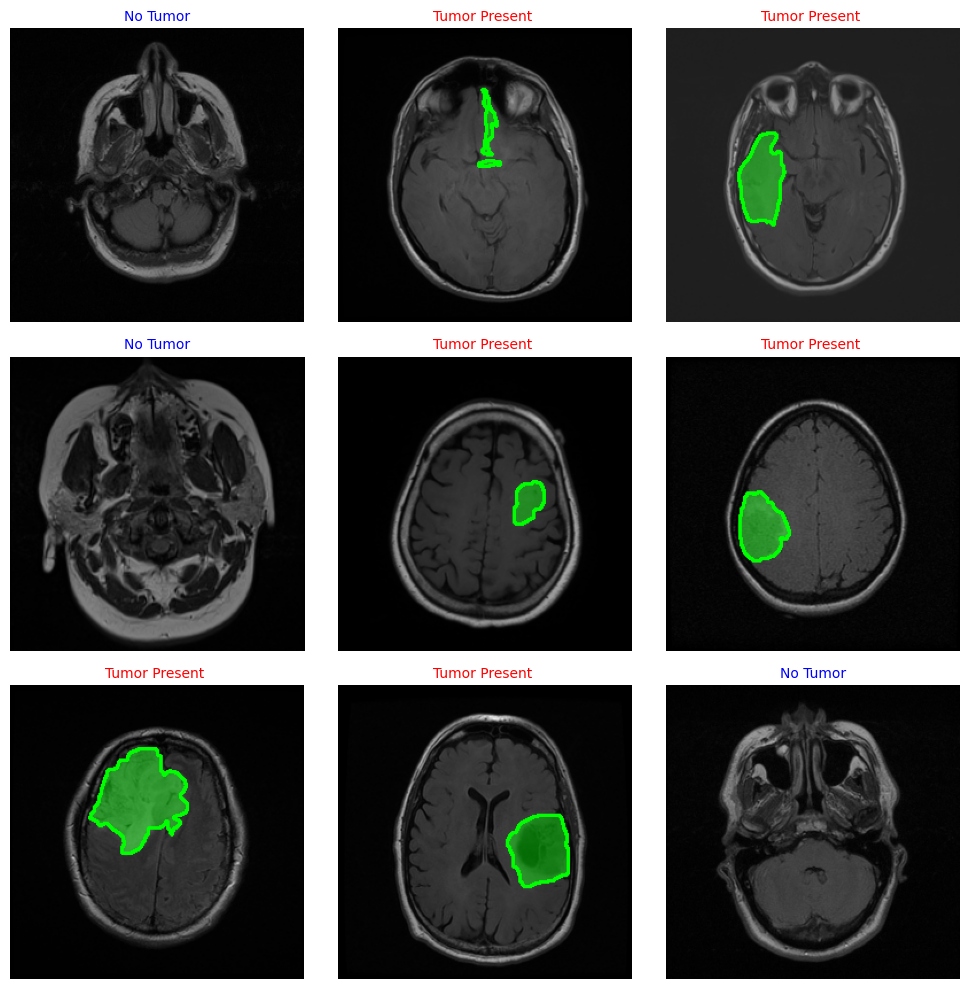


Visualization complete. The title now clearly indicates the ground truth status.


In [16]:

import matplotlib.pyplot as plt
import numpy as np
import random
import cv2 # Ensure OpenCV is imported for contour drawing

def visualize_mri_with_mask_overlay(images, masks, num_display_samples=9):
    """
    Displays MRI images with their corresponding ground truth masks overlaid,
    showing both contour and a semi-transparent fill, and displaying the tumor status.
    """
    # Select random indices for display
    indices = random.sample(range(len(images)), num_display_samples)
    
    # Setup figure for a grid (e.g., 3x3 for 9 samples)
    plt.figure(figsize=(10, 10)) # Adjust size for better visibility
    
    for i, idx in enumerate(indices):
        original_image = images[idx].squeeze() # Remove channel dim
        true_mask = masks[idx].squeeze()      # Remove channel dim

        # --- Determination of Tumor Status ---
        # If the sum of all mask pixels is greater than 0, a tumor is present.
        is_tumor = np.sum(true_mask) > 0
        status_label = "Tumor Present " if is_tumor else "No Tumor"
        
        # Convert original_image (0-1 float) to 8-bit for OpenCV (0-255 uint8)
        # Then convert to 3-channel BGR for drawing colored contours/fill
        image_display_bgr = cv2.cvtColor((original_image * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        
        # Find contours on the mask (Convert mask to 8-bit for cv2)
        mask_uint8 = (true_mask * 255).astype(np.uint8)
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Choose a fixed color for the tumor (e.g., Green for visibility)
        color = (0, 255, 0) # Green in BGR format
        
        # Draw contours and fill the mask area with transparency
        overlay = image_display_bgr.copy()
        output = image_display_bgr.copy()
        
        if is_tumor and contours:
            # Draw filled contour (mask area) with transparency
            cv2.drawContours(overlay, contours, -1, color, cv2.FILLED)
            alpha = 0.4 # Transparency factor for the fill
            output = cv2.addWeighted(overlay, alpha, output, 1 - alpha, 0)
            
            # Draw contour lines (outline) on top of the filled area
            cv2.drawContours(output, contours, -1, color, 2) # Thickness 2
        
        # Convert BGR image back to RGB for Matplotlib display
        image_final_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
        
        # Plotting
        plt.subplot(3, 3, i + 1) # 3 rows, 3 columns
        plt.imshow(image_final_rgb)
        
        # Display the tumor status in the title
        plt.title(f"{status_label}", fontsize=10, color='red' if is_tumor else 'blue')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("\nDisplaying MRI images with colored mask overlays and their tumor status...")
# Call the visualization function with your loaded images and masks
# (Assumes 'images_processed' and 'masks_processed' from Cell 1.3 are available)
visualize_mri_with_mask_overlay(images_processed, masks_processed, num_display_samples=9)

print("\nVisualization complete. The title now clearly indicates the ground truth status.")